
Understanding Multiple Linear Regression
Imagine you’re tasked with predicting house prices in a bustling real estate market. Buyers and sellers alike want accurate insights, but prices depend on multiple factors: square footage, number of bedrooms, and even the age of the house. How do we account for all these variables to make precise predictions?

This is where multiple linear regression comes in. Unlike simple linear regression, which analyzes a single factor, multiple linear regression incorporates multiple predictors to explain variations in the dependent variable.

The Model
The general formula for multiple linear regression is:

Y=β0+β1X1+β2X2+⋯+βnXn+ϵ 

Here’s what the terms mean:

Y: Dependent variable (e.g., house price)
X₁, X₂, ..., Xₙ: Independent variables (e.g., square footage, bedrooms, age of the house)
(β0) : Intercept, or the baseline value of Y when all X variables are zero
(β1,β2,...,βn) : Coefficients representing how much Y changes for a one-unit change in each X variable, holding others constant
(ϵ) : Error term accounting for variations not explained by the model

Real-World Application: House Price Prediction
Imagine building a model to predict house prices:

The Equation
Price=β0+β1(Square Footage)+β2(Bedrooms)+β3(Age)+ϵ 

Interpretation
(β1) *: For every additional square foot, the house price increases by  (β1)  dollars, assuming other variables remain constant.
(β2) : Adding a bedroom increases the price by  (β2)  dollars.
(β3) : Each year of age reduces the price by  (β3)  dollars.
This approach provides actionable insights for buyers, sellers, and agents, enabling data-driven decisions.

Beyond Basics
Multiple linear regression isn’t limited to simple predictors. It can accommodate:

Interaction Terms: To capture relationships between predictors.
Polynomial Terms: For curvilinear relationships.
Transformations: To address non-linearity or scale differences.
Ready to see this in action? Explore a practical example using the California Housing Dataset in the next section, and bring the concepts to life!

Example: Multiple Linear Regression with the California Housing Dataset
As a data scientist working for a real estate firm, we've been tasked with developing a model that can predict housing prices in California based on various factors such as location, number of bedrooms and bathrooms, square footage, and more. Our goal is to create a reliable and accurate model that can help homebuyers and sellers make informed decisions in the competitive California housing market.

We'll be working with the California Housing Dataset, which contains information on housing prices and features from various regions in California. Your task is to implement a Multiple Linear Regression model using this dataset and evaluate its performance. Lets create a model that accurately predicts California housing prices and helps people achieve their California dream

In [2]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Load the Housing dataset
data = fetch_california_housing(as_frame=True)
df = data.frame
df.shape

(20640, 9)

In [6]:
print("First five rows of the dataset:")
df.head()

First five rows of the dataset:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [7]:
# Display basic information about the dataset
print("\nDataset information:")
print(df.info())



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None


In [8]:
# Display summary statistics
print("\nSummary statistics:")
print(df.describe())


Summary statistics:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude   MedHouseVal  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532      1.153956  
min        

In [9]:
# Splitting the dataset into features (X) and target (y)
X = df.drop(columns=["MedHouseVal"])
y = df["MedHouseVal"]

X.head(5)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [10]:
# Splitting into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
X_train.shape

(16512, 8)

In [12]:
# Train a Multiple Linear Regression model

# Initializing and training the linear regression model
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [13]:
lr.intercept_

-37.02327770606394

In [14]:
pd.DataFrame(data=lr.coef_, index=X_train.columns)

,0
MedInc,0.448675
HouseAge,0.009724
AveRooms,-0.123323
AveBedrms,0.783145
Population,-0.000002
AveOccup,-0.003526
Latitude,-0.419792
Longitude,-0.433708


In [15]:
# Making predictions on the test set
y_pred = lr.predict(X_test)

In [16]:
y_pred

array([0.71912284, 1.76401657, 2.70965883, ..., 4.46877017, 1.18751119,
       2.00940251])

In [17]:
# Evaluate the model
# Calculating evaluation metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [18]:
print("\nModel Evaluation:")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared (R2): {r2:.2f}")


Model Evaluation:
Mean Squared Error (MSE): 0.56
Mean Absolute Error (MAE): 0.53
R-squared (R2): 0.58


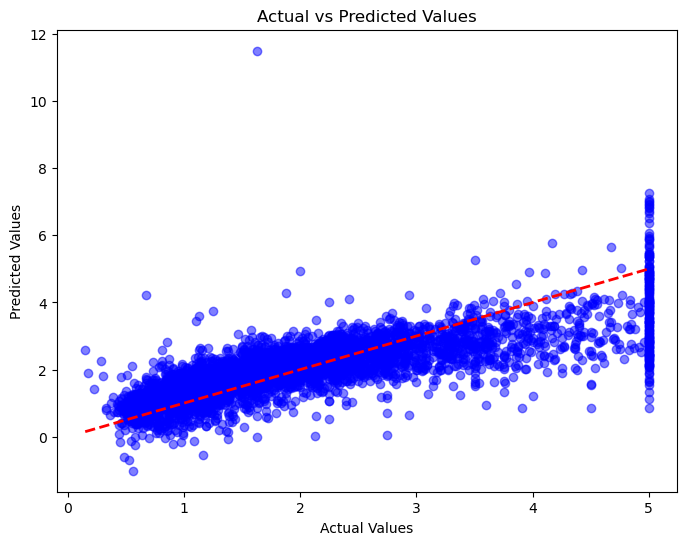

In [19]:
# Plotting actual vs predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='b')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.title("Actual vs Predicted Values")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

plt.show()

Introducing Ridge, Lasso, and Elastic Net Regression
1. Ridge Regression (L2 Regularization)
Imagine you're building a machine learning model, but it starts "overfitting" — meaning it performs great on the training data but poorly on new, unseen data. Ridge regression helps fix this by adding a penalty to the model for having overly large coefficients (the numbers that determine the importance of features).

It tries to keep the coefficients small but not exactly zero.
Think of it like trying to control how much influence each feature has, without completely removing any of them.
Key Point:
Ridge works well when all features are important but need to be controlled.

2. Lasso Regression (L1 Regularization)
Lasso regression also adds a penalty, but instead of just shrinking coefficients like Ridge, it can shrink some of them exactly to zero. This means it can automatically remove unimportant features from the model.

Imagine you're packing for a trip but have limited space. Lasso helps you decide which items (features) to leave behind to make your suitcase manageable.
Key Point:
Lasso works well when you suspect that only a few features are truly important, and you want to ignore the rest.

3. Elastic Net Regression
Elastic Net is like a combination of Ridge and Lasso. It adds both types of penalties, balancing between:

Shrinking coefficients like Ridge.

Selecting important features like Lasso.

It's useful when there are many correlated features, and you want the benefits of both Ridge and Lasso.

Key Point:
Elastic Net is a good choice when you're unsure whether Ridge or Lasso alone will work best.

Summary Table
Regression Type	Key Feature	When to Use
Ridge (L2)	Shrinks coefficients but keeps them non-zero	When all features matter, but need control
Lasso (L1)	Shrinks coefficients to zero, removing unimportant features	When only a few features are important
Elastic Net	Combines Ridge and Lasso	When features are correlated or you're unsure which regularization to use


In [20]:
#Adding Lasso, Ridge and ElasticNet Models
# Initializing the models
lasso = Lasso(alpha=0.1)
ridge = Ridge(alpha=1.0)
elastic_net = ElasticNet(alpha=0.1, l1_ratio=0.5)

In [21]:
# Implement Lasso Regression
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)


# Evaluating Lasso
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)
print("\nLasso Regression:")
print(f"MSE: {mse_lasso:.2f}, R2: {r2_lasso:.2f}")



Lasso Regression:
MSE: 0.61, R2: 0.53


In [22]:
# Implement Ridge Regression
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

# Evaluating Ridge
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)
print("\nRidge Regression:")
print(f"MSE: {mse_ridge:.2f}, R2: {r2_ridge:.2f}")


Ridge Regression:
MSE: 0.56, R2: 0.58


In [23]:
# Implement Elastic Net Regression
elastic_net.fit(X_train, y_train)
y_pred_elastic = elastic_net.predict(X_test)


# Evaluating ElasticNet
mse_elastic = mean_squared_error(y_test, y_pred_elastic)
r2_elastic = r2_score(y_test, y_pred_elastic)
print("\nElasticNet Regression:")
print(f"MSE: {mse_elastic:.2f}, R2: {r2_elastic:.2f}")


ElasticNet Regression:
MSE: 0.57, R2: 0.56


Comparing the Performance of Different Models
Comparing the performance of different models using Mean Squared Error (MSE) and R-Squared (R2).


Model Comparison:
               Model       MSE        R2
0              Ridge  0.555803  0.575855
1  Linear Regression  0.555892  0.575788
2         ElasticNet  0.573099  0.562656
3              Lasso  0.613512  0.531817


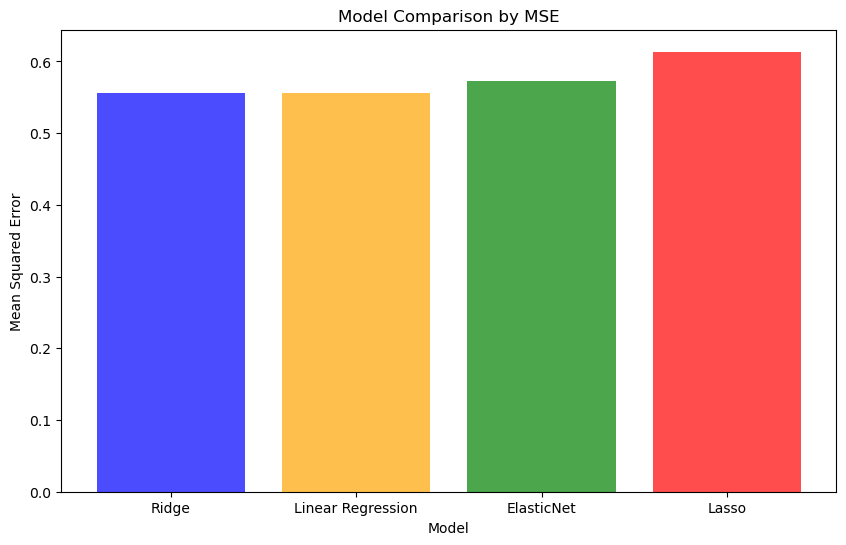

In [24]:
### Cell 8: Compare models
# Creating a comparison DataFrame
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Lasso', 'Ridge', 'ElasticNet'],
    'MSE': [mse, mse_lasso, mse_ridge, mse_elastic],
    'R2': [r2, r2_lasso, r2_ridge, r2_elastic]
})

# Sorting by MSE
comparison = comparison.sort_values(by='MSE').reset_index(drop=True)

# Displaying the comparison table
print("\nModel Comparison:")
print(comparison)

# Visualizing the comparison
plt.figure(figsize=(10, 6))
plt.bar(comparison['Model'], comparison['MSE'], color=['blue', 'orange', 'green', 'red'], alpha=0.7)
plt.title("Model Comparison by MSE")
plt.ylabel("Mean Squared Error")
plt.xlabel("Model")
plt.show()

The comparison table shows the performance of four regression models based on two metrics: Mean Squared Error (MSE) and R-squared (R²).

Ridge Regression:

MSE: 0.5558 (lowest, indicating the best fit among the models in terms of error minimization).
R²: 0.5759 (slightly better than Linear Regression).
Ridge regression performs the best overall, balancing regularization and accuracy.

Linear Regression:

MSE: 0.5559 (very close to Ridge, but slightly higher).
R²: 0.5758.
While simple Linear Regression is close to Ridge, it lacks regularization, which could make it less robust in other scenarios.

ElasticNet Regression:

MSE: 0.5731.
R²: 0.5627.
ElasticNet combines both Lasso and Ridge regularization. Its slightly higher MSE suggests it is not as effective for this dataset, likely because the dataset does not require as much sparsity or feature selection.

Lasso Regression:

MSE: 0.6135 (highest among the models, indicating the largest error).
R²: 0.5318.
Lasso performs the worst, possibly due to its tendency to zero out coefficients, which may have eliminated useful features.

Key Takeaways:
Ridge Regression outperforms the other models slightly, demonstrating that regularization improves performance by controlling overfitting.
Linear Regression is nearly equivalent but might not generalize as well without regularization.
ElasticNet offers moderate performance, potentially useful when sparsity and feature selection are priorities.
Lasso Regression struggles here, suggesting that penalizing coefficients too strongly is suboptimal for this dataset.